# Domain diversity and visual representation of OT

The first part of this notebook includes an exploration of the domains' diversity exemplified by the difference in appearance of some images belonging to the train set. Next, it includes the RGB point cloud representation of the images and how this relates to OT. Finally, it includes a visual analysis of the distribution of domains in different phenological stages, as well as examples of said stages. 

## Showing domain diversity of the dataset

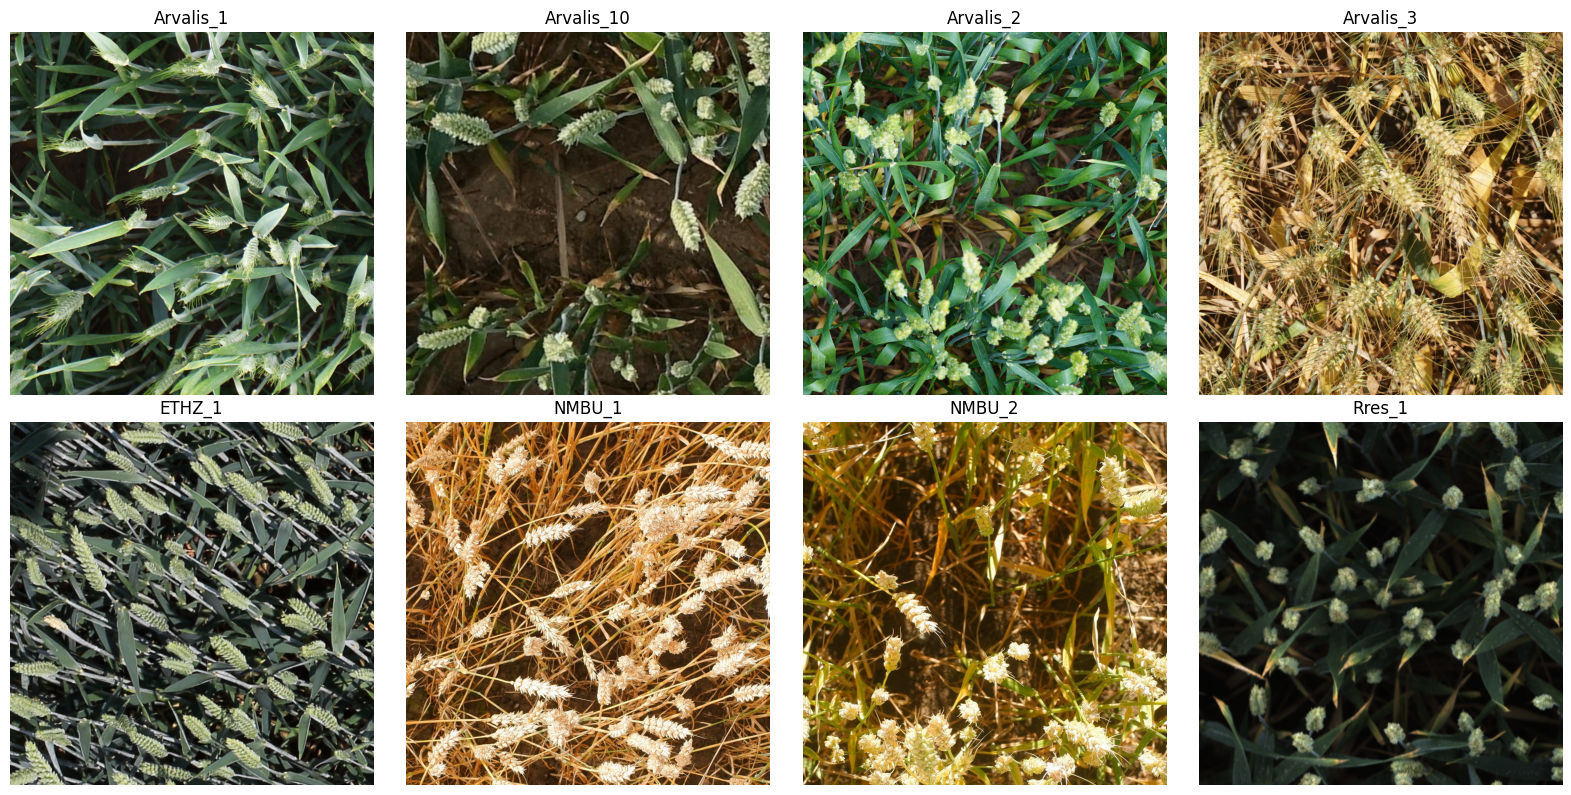

In [ ]:
from utils import show_domain_images

# Path to the csv file and image folder of the train, valid or test set (depending on which one we want to explore)
csv_train = "../gwhd_2021/competition_train.csv"
train_folder = "../gwhd_2021/Original/train/images/"

# Saving and showing the image panel that exemplifies the domain diversity of the dataset
# First number of the function is for the number of different domains we want to see. The second number is for the number of images per domain
img_panel = show_domain_images(csv_train, train_folder, 8, 1)

# Define a path to save the image panel 
img_panel.savefig("figs/domain_diversity.png")
plt.show()

## The OT problem for images represented as point clouds

In [10]:
# Necessary libraries and modules
import os
import pandas as pd
import numpy as np
import random
import imageio
import torch
import matplotlib.pyplot as plt
from geomloss import SamplesLoss
from PIL import Image
from utils import RGB_cloud, display_cloud, display_image, color_transfer

In [11]:
# Ensures GPU support is available and use cuda tensors in this case
use_cuda = torch.cuda.is_available()
dtype = torch.cuda.FloatTensor if use_cuda else torch.FloatTensor
sampling = 8 if not use_cuda else 1

# Apply domain adaptation to an image of a source domain to make it look like one of a target domain (making them have the same color palette)
def OT_and_save(source_image_path, target_image_path, img_destination):
    X_i = RGB_cloud(source_image_path, sampling, dtype)
    Y_j = RGB_cloud(target_image_path, sampling, dtype)

    # Blur and reach relate to ε (entropy regularization) and ρ (unbalanced transport) respectively, these parameters regulate the domain adaptation
    # change ε and ρ to see different effects on the adapted image and modifications on its point cloud shape  
    new_cloud = color_transfer(X_i, Y_j, SamplesLoss("sinkhorn", blur=0.2, reach=None))
    
    # The new RGB cloud must be converted to a uint8 image so it can be saved
    W = int(np.sqrt(len(new_cloud)))
    img_matrix = new_cloud.view(W, W, 3).detach().cpu().numpy()
    new_image = np.clip(img_matrix, 0, 1)
    final_image = (new_image * 255).astype(np.uint8)

    # Save the final image so we can compare point clouds
    imageio.imwrite(img_destination, final_image)
    print(f'New OT image {img_destination} successfully created')

In [12]:
# This code is used to get random source and target images from the chosen image folder  
'''img_folder = "../gwhd_2021/Original/train/images/"
files = os.listdir(img_folder)
selected_imgs = random.sample(files, 2)
img_paths = [os.path.abspath(os.path.join(img_folder, f)) for f in selected_imgs]
source_img = img_paths[0]
target_img = img_paths[1]'''

# You can also use specific source and target images by defining their paths 
source_img = "../gwhd_2021/Original/train/images/cea3dd63614c12ed87b9a129c1aa75d3ec55b5a90e52b986af01383d14101ba0.png"
target_img = "../gwhd_2021/Original/train/images/25980f37df3f15f2c38ab2ef6a84bbb81e8d70838289ba7964e4fb8f3e3c5553.png"
# Define a path to save the adapted image
save_path = "figs/adapted_image.png"

OT_and_save(source_img, target_img, save_path)

New OT image figs/adapted_image.png successfully created


/tmp/ipykernel_196536/3587705716.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


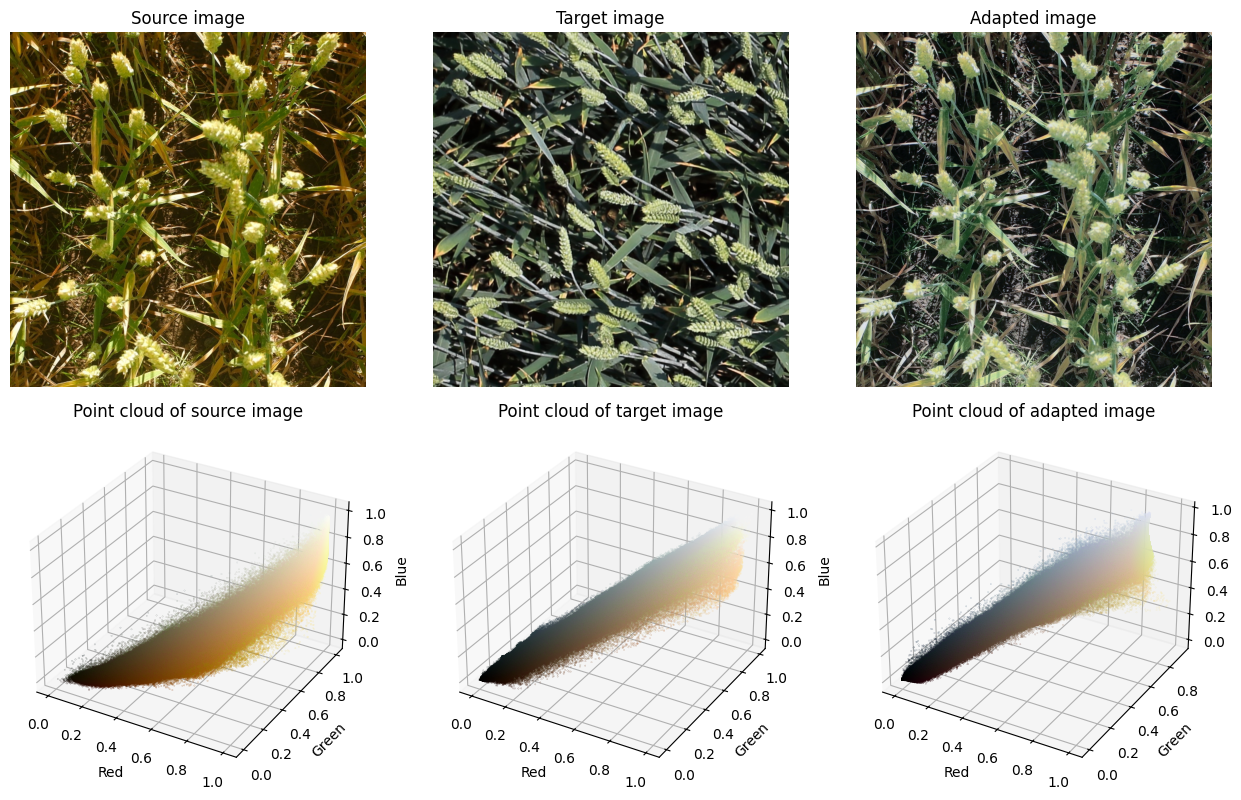

In [15]:
# Create the point clouds for the source_target and adapted images so we can compare them 
X_i = RGB_cloud(source_img, sampling, dtype)
Y_j = RGB_cloud(target_img ,sampling, dtype)
Z_k = RGB_cloud(save_path, sampling, dtype)

# Create a panel to show both the images and their corresponding point clouds 
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
ax = fig.add_subplot(2, 3, 1)
display_image(ax, X_i)
ax.set_title("Source image")
ax.axis('off') 

ax = fig.add_subplot(2, 3, 2)
display_image(ax, Y_j)
ax.set_title("Target image")
ax.axis('off') 

ax = fig.add_subplot(2, 3, 3)
display_image(ax, Z_k)
ax.set_title("Adapted image")
ax.axis('off') 

ax = fig.add_subplot(2, 3, 4, projection="3d")
display_cloud(ax, X_i)
ax.set_title("Point cloud of source image")
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel("Blue", rotation=90)

ax = fig.add_subplot(2, 3, 5, projection="3d")
display_cloud(ax, Y_j)
ax.set_title("Point cloud of target image")
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel("Blue", rotation=90)

ax = fig.add_subplot(2, 3, 6, projection="3d")
display_cloud(ax, Z_k)
ax.set_title("Point cloud of adapted image")
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel("Blue", rotation=90)

plt.tight_layout()
fig.savefig("figs/point_cloud_OT.png", bbox_inches='tight')
plt.show()

## Phenological stage distribution and representative images by stage

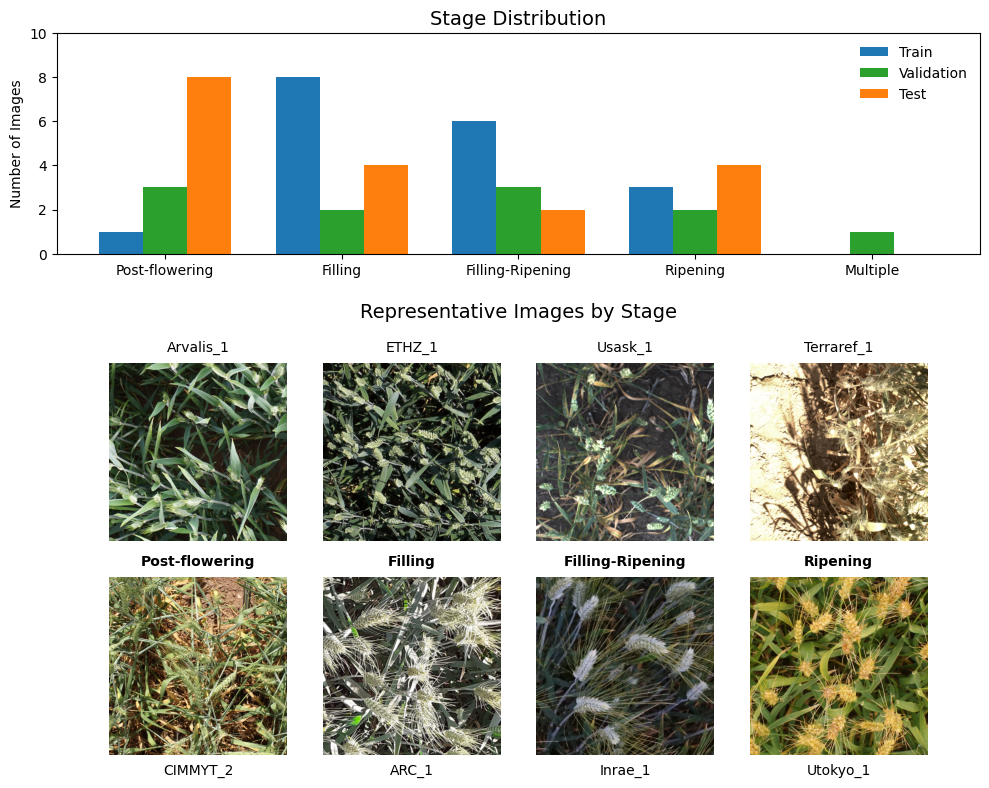

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# Phenological Stage Distribution
stages_chart = ["Post-flowering", "Filling", "Filling-Ripening", "Ripening", "Multiple"]
train_counts = [1, 8, 6, 3, 0]  # Train split
val_counts   = [3, 2, 3, 2, 1]  # Validation split
test_counts  = [8, 4, 2, 4, 0]  # Test split

x = np.arange(len(stages_chart))
width = 0.25

fig = plt.figure(figsize=(10, 8))


ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=1)
ax1.bar(x - width, train_counts, width, label='Train', color='#1f77b4')
ax1.bar(x, val_counts, width, label='Validation', color='#2ca02c')
ax1.bar(x + width, test_counts, width, label='Test', color='#ff7f0e')

ax1.set_ylabel('Number of Images')
ax1.set_xticks(x)
ax1.set_xticklabels(stages_chart)
ax1.set_title('Stage Distribution', fontsize=14)
ax1.legend(frameon=False)
ax1.set_ylim(0, max(train_counts + val_counts + test_counts) + 2)


# Example images per stage
stages_panel = ["Post-flowering", "Filling", "Filling-Ripening", "Ripening"]
train_folder = "../gwhd_2021/Original/train/images/"
valid_folder = "../gwhd_2021/Original/valid/images/"
test_folder = "../gwhd_2021/Original/test/images/"

# Example: fake paths for 2 rows × len(stages) columns
# Replace these strings with your actual image file paths
image_paths = [
    [
        "../gwhd_2021/Original/train/images/cdadbd6956e34e27ba215da4e7752f21ee937466d1a8367be221fbefa62e7cf7.png", 
        "../gwhd_2021/Original/train/images/f6d2ba6584330be0822b800ed39266e5452a75debab4d3148f38ecd1eefdb43f.png",
        "../gwhd_2021/Original/valid/images/c27be6399eb5c54ee7119196f49d693eba48d9b817b292862d0d7b2fedfd32e4.png", 
        "../gwhd_2021/Original/test/images/a78f889b83294e2bdf12ceb6e0eeea8e8330e86847380ac1aed6deb50b9aa1f0.png"
    ],
    [
        "../gwhd_2021/Original/test/images/aa6e74fe6e06278a362029b4707405f3b56869d65e3b312897a6bd547b01a07f.png", 
        "../gwhd_2021/Original/test/images/e6e9c9c6c4622247326daff48e1a2a0fa9fa300e0780ca75517d3a7eced07bac.png",
        "../gwhd_2021/Original/train/images/04287f47491fff0f8e9bedabf5db22648fd35b2eb8a91f8c51b89505ec9dce9d.png", 
        "../gwhd_2021/Original/valid/images/1e32bf96f86582325f3f1401d8aed32003f9f55c30140d06bac935aae4cbf8dc.png"
    ]
]

ax2 = plt.subplot2grid((3, 1), (1, 0), rowspan=2)

rows, cols = 2, len(stages_panel)
box_size = 1
gap = 0.2

domain_ids = [
    ["Arvalis_1", "ETHZ_1", "Usask_1", "Terraref_1"],
    ["CIMMYT_2", "ARC_1", "Inrae_1", "Utokyo_1"]
]   

for row in range(rows):
    for col in range(cols):
        left = col * (box_size + gap)
        bottom = (rows - 1 - row) * (box_size + gap)

        img_path = image_paths[row][col]
        if os.path.exists(img_path):
            img = Image.open(img_path)
            img_array = np.array(img)
            ax2.imshow(img_array, extent=(left, left + box_size, bottom, bottom + box_size))
        # Stage label only in top row
        if row == 1:
            ax2.text(left + box_size/2, bottom + box_size + 0.05,
                     stages_panel[col], ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Domain ID
        if row == 0:
    # Top row → put above image
            ax2.text(left + box_size / 2, bottom + box_size + 0.05,
                    domain_ids[row][col], fontsize=10, color='black',
                    ha='center', va='bottom')
        else:
            # Bottom row → put below image
            ax2.text(left + box_size / 2, bottom - 0.05,
                    domain_ids[row][col], fontsize=10, color='black',
                    ha='center', va='top')

ax2.set_xlim(-0.1, cols * (box_size + gap) - gap + 0.1)
ax2.set_ylim(-0.1, rows * (box_size + gap) - gap + 0.4)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Representative Images by Stage', fontsize=14, y=0.93)

plt.tight_layout()
fig.savefig("figs/domain_distribution_stages.png", bbox_inches='tight')
plt.show()